# Inferring the errors: a global scale, and an unrecognised source

Sometimes the data scatter more than the reported errors can explain, and we do
not believe any individual point is *wrong* — we believe the error bars are.
That is a different question from the one in `robust_likelihoods`, where we
asked what to do about a few bad points, and it wants a different model.

We try two answers here.  The blunt one is a single scale on every reported
error.  The targeted one is an **unrecognised source of uncertainty**: a fully
correlated component attached to the experiments we suspect, which shifts the
evaluated mean as well as its width.

Recipes: 34

In [1]:
import emcee
import matplotlib.pyplot as plt
import numpy as np
import plotstyle
from scipy import stats

import rxmc as rx
from rxmc import terms as T

plotstyle.use()

## The same twenty-five points, three of them wrong

We start from the dataset of `robust_likelihoods`: a line with 5 % noise and
three points pushed up by ten times their error.

In [2]:
rng = np.random.default_rng(21)
m_true, b_true = 1.0, 0.5
x = np.linspace(0.0, 4.0, 25)
noise = 0.05
y = m_true * x + b_true + rng.normal(0.0, noise, x.size)
outliers = np.array([5, 12, 19])
y[outliers] += np.array([10.0, 12.0, 9.0]) * noise
data = rx.Dataset(x, y, np.full(x.size, noise), label="with outliers")

m = rx.Parameter("m", prior=stats.norm(1.0, 1.0), latex="m")
b = rx.Parameter("b", prior=stats.norm(0.0, 1.0), latex="b")
line = rx.Model(lambda x, m, b: m * x + b, [m, b])
comp = rx.Comparison(data, line)
nu = rx.Parameter("nu", bounds=(1.0, 100.0), latex=r"\nu")

In [3]:
def fit(problem, seed, n_walkers=24, n_steps=2000):
    sampler = emcee.EnsembleSampler(n_walkers, problem.ndim, problem.log_posterior)
    sampler.random_state = np.random.RandomState(seed).get_state()
    sampler.run_mcmc(problem.sample_prior(n_walkers, rng=seed), n_steps, progress=False)
    return sampler.get_chain(discard=n_steps // 3, thin=5, flat=True)


x_fine = np.linspace(-0.5, 4.5, 60)
on_fine = line.bind(x_fine)
y_true_fine = on_fine(m_true, b_true)

## Inferring the errors (recipe 34)

Another option we could take when we notice that the spread in the data is not
consistent with the reported experimental uncertainty is to try to infer the
uncertainty along with the model parameters.  There are many ways to do this:
this implies coming up with a model for the distribution governing the unknown
discrepancy between the model and the data.  Careful — this discrepancy can
include *both* experimental uncertainty and model misspecification.  We will
take a closer look at the latter in other notebooks.  In this case, we have a
correctly specified model, we just have outliers.

One simple thing we can do is add a parameter for **a global scale** on the
reported errors.  This allows us to inflate the experimental errors while
inferring the model parameters to maximise the posterior.

Under the Gaussian likelihood the scale has to grow until every point's error
covers the outliers, and the scale will therefore be poorly determined.  Under
the Student-t, the tail shares the work, so the scale is smaller and better
determined.  Either way a global scale inflates every point equally, which is
why it is judged poor evaluation practice next to a targeted approach — for
instance the outlier rejection of `robust_likelihoods`, or the USU component
below.

In [4]:
log_s = rx.Parameter("log_s", prior=stats.norm(0.0, 0.5), latex=r"\log s")
scaled = rx.Term(lambda c, ls: np.exp(ls) * comp.y_err, (log_s,), kind="diag", on=comp)
p_scale_gauss = rx.Problem([rx.Constraint([comp], terms=[scaled], statistical=False)])
p_scale_t = rx.Problem(
    [
        rx.Constraint(
            [comp], terms=[scaled], statistical=False, likelihood=rx.StudentT(nu)
        )
    ]
)

In [5]:
for name, p, seed in (("Gaussian", p_scale_gauss, 3), ("Student-t", p_scale_t, 4)):
    s = fit(p, seed)
    lo, med, hi = np.percentile(np.exp(s[:, p.columns(log_s)]), [16, 50, 84])
    print(f"{name:10s} error scale s = {med:.2f}  (68 % interval {lo:.2f} to {hi:.2f})")

Gaussian   error scale s = 3.22  (68 % interval 2.83 to 3.68)


Student-t  error scale s = 2.91  (68 % interval 2.18 to 3.48)


## A component the experiment did not recognise

Suppose instead that we were actually comparing two data sets, one containing
the normal points and one containing the outlying points.  What we might then do
is to recognise that the difference in the experimental process corresponding to
the two data sets — for example a difference in experimental technique — could
lead to **an Unrecognised Source of Uncertainty (USU)**.

In our case, we can model this per-dataset USU as an unknown per-dataset offset.
A sampled `T.offset` on that technique's comparisons is a fully correlated
component *inside* the covariance, which shifts the evaluated mean as well as its
width.  A global scale cannot do that.

This is the shape recommended by [Capote et al.
(2020)](https://arxiv.org/abs/1911.01825) for unrecognised uncertainties in
evaluated nuclear data, and discussed by [Hanson
(2007)](https://arxiv.org/abs/0712.0021); the point both make is that the
component has to live *in* the covariance of the fit, not be added to the result
afterwards.

In [6]:
x_a, x_b = np.linspace(0.0, 4.0, 13), np.linspace(0.15, 3.85, 12)
y_a = m_true * x_a + b_true + rng.normal(0.0, noise, x_a.size)
y_b = (
    m_true * x_b + b_true + 0.25 + rng.normal(0.0, noise, x_b.size)
)  # a 0.25 offset nobody reported
d_a = rx.Dataset(
    x_a, y_a, np.full(x_a.size, noise), label="technique A", meta={"technique": "A"}
)
d_b = rx.Dataset(
    x_b, y_b, np.full(x_b.size, noise), label="technique B", meta={"technique": "B"}
)
comps = [rx.Comparison(d_a, line), rx.Comparison(d_b, line)]

In [7]:
# we may have some prior reason to suspect that B contains the unknown offset,
# but not A, so we will apply it only to B
log_usu = rx.Parameter(
    "log_usu_B", prior=stats.norm(np.log(0.2), 1.0), latex=r"\log\delta_B"
)
usu = T.offset(log_usu, on=[c for c in comps if c.data.meta["technique"] == "B"])

# the global diagonal uncertainty scale from before, for comparison
scaled_ab = [
    rx.Term(
        lambda c, ls, comp=comp: np.exp(ls) * comp.y_err, (log_s,), kind="diag", on=comp
    )
    for comp in comps
]

problems = {
    "as stated": rx.Problem([rx.Constraint(comps)]),
    "global scale": rx.Problem(
        [rx.Constraint(comps, terms=scaled_ab, statistical=False)]
    ),
    "USU offset on B": rx.Problem([rx.Constraint(comps, terms=[usu])]),
}

In [8]:
bands = {}
for (name, p), seed in zip(problems.items(), (5, 6, 7)):
    s = fit(p, seed)
    cols = p.columns(line.params)
    print(
        f"{name:16s} m = {s[:, cols[0]].mean():.3f} +/- {s[:, cols[0]].std():.3f}, "
        f"b = {s[:, cols[1]].mean():.3f} +/- {s[:, cols[1]].std():.3f}"
    )
    # the line's own band, compared with the truth rather than with the data
    lo, hi = rx.predictive.grid_draws(
        p, on_fine, x_fine, s[::10], model_only=True, levels=(5, 95)
    )
    bands[name] = (lo - y_true_fine, hi - y_true_fine)

as stated        m = 0.991 +/- 0.008, b = 0.637 +/- 0.020


global scale     m = 0.989 +/- 0.036, b = 0.654 +/- 0.232


USU offset on B  m = 0.991 +/- 0.008, b = 0.526 +/- 0.022


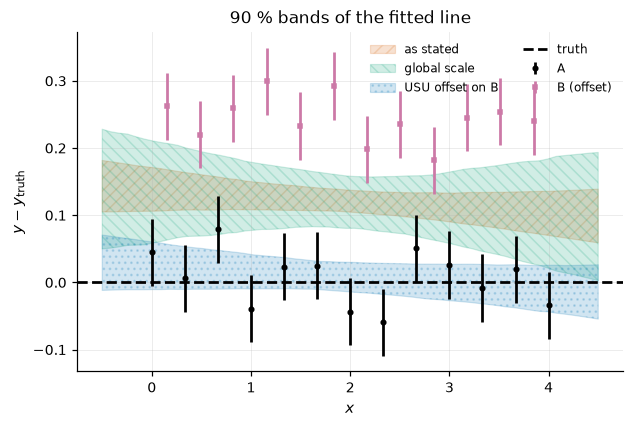

In [9]:
fig, ax = plt.subplots()
for (name, (lo, hi)), colour, hatch in zip(
    bands.items(),
    (plotstyle.COLOURS[1], plotstyle.COLOURS[2], plotstyle.COLOURS[0]),
    plotstyle.HATCHES,
):
    plotstyle.band(ax, x_fine, lo, hi, color=colour, hatch=hatch, label=name)
on_a, on_b = line.bind(d_a.x), line.bind(d_b.x)
ax.errorbar(
    d_a.x, d_a.y - on_a(m_true, b_true), d_a.y_err, fmt="o", ms=3, color="k", label="A"
)
ax.errorbar(
    d_b.x,
    d_b.y - on_b(m_true, b_true),
    d_b.y_err,
    fmt="s",
    ms=3,
    color=plotstyle.COLOURS[3],
    label="B (offset)",
)
ax.axhline(0.0, ls="--", color="k", label="truth")
ax.set(
    xlabel="$x$",
    ylabel=r"$y - y_\mathrm{truth}$",
    title="90 % bands of the fitted line",
)
ax.legend(fontsize=8, ncol=2, loc="upper right")
plt.show()

By using our prior knowledge that data set `B` may have an unknown offset
(USU), but data set `A` does not, we are able to cover the truth.

The contrast with the global scale is the whole point.  The scale can only make
every error bar bigger, so it buys coverage by making the answer vaguer
everywhere, including where the data were fine.  The USU offset says something
specific — *this technique may sit at the wrong level* — and because that
statement lives inside the covariance, it moves the fitted line as well as
widening it.

## Takeaways

- "The errors are too small" is a modelling claim, and we have to say what kind
  of error we mean.  A global scale and a per-technique offset are different
  claims and give different answers.
- A global scale is one column that multiplies every reported error.  Under a
  Gaussian it has to grow until it covers the worst points, and it ends up
  poorly determined; under a Student-t the tail does part of the work.
- A USU component is a sampled `T.offset` on the comparisons of one technique: a
  fully correlated piece of the covariance, which shifts the mean as well as the
  width.
- Neither is a substitute for asking whether the points are simply wrong.  That
  question is `robust_likelihoods`, next door.